In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("LHCb")

import os
os.makedirs("../plots", exist_ok=True)

In [2]:
file_path = "D:/b_meson_analysis/data/B2HHH_MagnetDown.root"

tree = uproot.open(file_path)["DecayTree"]
df = tree.arrays(library="pd")

print("Data loaded:", df.shape)
df.head()

Data loaded: (5135823, 26)


,B_FlightDistance,B_VertexChi2,H1_PX,H1_PY,H1_PZ,H1_ProbK,H1_ProbPi,H1_Charge,H1_IPChi2,H1_isMuon,...,H2_IPChi2,H2_isMuon,H3_PX,H3_PY,H3_PZ,H3_ProbK,H3_ProbPi,H3_Charge,H3_IPChi2,H3_isMuon
0,25.301004,1.497280,375.284205,831.308481,51820.233718,0.038616,0.888755,-1,212.776776,0,...,5878.170539,0,-208.210960,-2586.359121,105848.271681,0.193004,0.138845,1,61.157888,1
1,94.690700,1.383338,-4985.130785,5853.750057,326157.454706,0.073556,0.039064,-1,373.815885,1,...,183.579026,1,-175.018535,1325.178792,87681.561846,0.080397,0.758603,1,185.092016,0
2,8.284490,5.187101,-1265.456544,2330.050788,90762.658032,0.030095,0.636693,1,53.187855,0,...,564.594503,0,-1383.996490,-71.081104,85574.929582,0.750751,0.399602,-1,1.481413,0
3,5.590769,7.129099,-720.797259,3413.790588,86793.058768,0.211414,0.350969,-1,6.232666,0,...,30.221705,0,398.775944,-1134.914464,14653.316611,0.005698,0.964705,1,468.174038,0
4,3.013242,10.988701,397.754571,1791.373059,40040.364159,0.005697,0.933102,-1,3.137287,0,...,737.287443,0,477.148467,2113.439057,24462.076980,0.002979,0.918983,1,60.530372,0


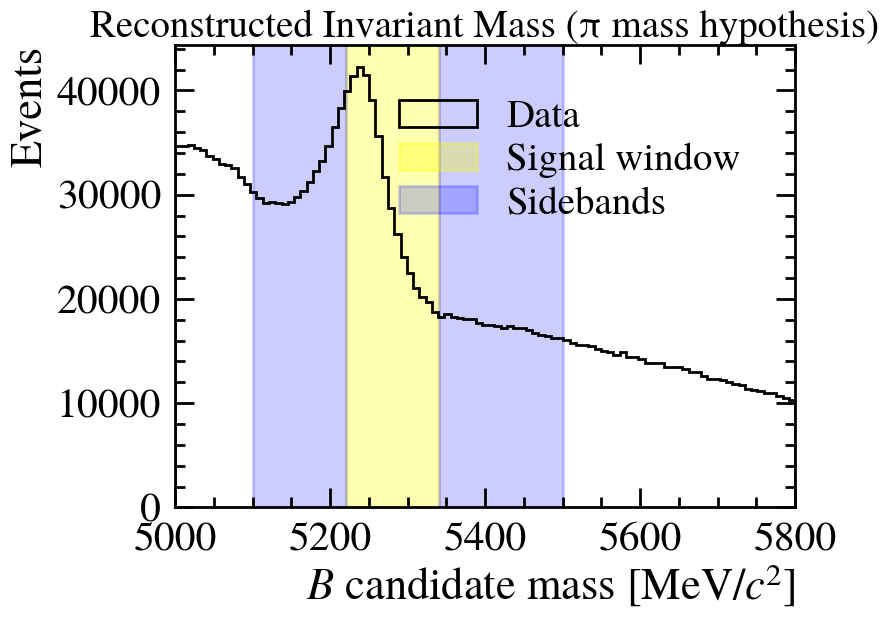

In [4]:
# ================================
# Reconstruct B invariant mass
# ================================

import numpy as np
import matplotlib.pyplot as plt

# Pion mass hypothesis (MeV)
m_pi = 139.57

def compute_energy(px, py, pz, m):
    p2 = px**2 + py**2 + pz**2
    return np.sqrt(p2 + m**2)

# Compute energies for each track
E1 = compute_energy(df["H1_PX"], df["H1_PY"], df["H1_PZ"], m_pi)
E2 = compute_energy(df["H2_PX"], df["H2_PY"], df["H2_PZ"], m_pi)
E3 = compute_energy(df["H3_PX"], df["H3_PY"], df["H3_PZ"], m_pi)

# Total momentum components
px_tot = df["H1_PX"] + df["H2_PX"] + df["H3_PX"]
py_tot = df["H1_PY"] + df["H2_PY"] + df["H3_PY"]
pz_tot = df["H1_PZ"] + df["H2_PZ"] + df["H3_PZ"]

# Total energy
E_tot = E1 + E2 + E3

# Invariant mass calculation
df["B_M"] = np.sqrt(np.maximum(E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2), 0))


# ================================
# Plot invariant mass
# ================================

plt.figure(figsize=(8,6))

bins = np.linspace(5000, 5800, 100)

plt.hist(df["B_M"], bins=bins, histtype="step", color="black", label="Data")

# Define regions
signal_window = (5220, 5340)
sideband_low = (5100, 5220)
sideband_high = (5340, 5500)

# Highlight regions
plt.axvspan(*signal_window, color="yellow", alpha=0.3, label="Signal window")
plt.axvspan(*sideband_low, color="blue", alpha=0.2, label="Sidebands")
plt.axvspan(*sideband_high, color="blue", alpha=0.2)

plt.xlabel(r"$B$ candidate mass [MeV/$c^2$]")
plt.ylabel("Events")
plt.title("Reconstructed Invariant Mass (π mass hypothesis)")

plt.legend()
plt.savefig("D:/b_meson_analysis/plots/invariant_mass.png", dpi=300)
plt.show()

In [5]:
# ================================
# Define signal and sideband regions
# ================================

signal_window = (5220, 5340)
sideband_low = (5100, 5220)
sideband_high = (5340, 5500)

df_signal = df[(df["B_M"] > signal_window[0]) & (df["B_M"] < signal_window[1])]

df_sideband = df[
    ((df["B_M"] > sideband_low[0]) & (df["B_M"] < sideband_low[1])) |
    ((df["B_M"] > sideband_high[0]) & (df["B_M"] < sideband_high[1]))
]

print("Signal region:", df_signal.shape)
print("Sideband:", df_sideband.shape)

Signal region: (444867, 27)
Sideband: (814049, 27)


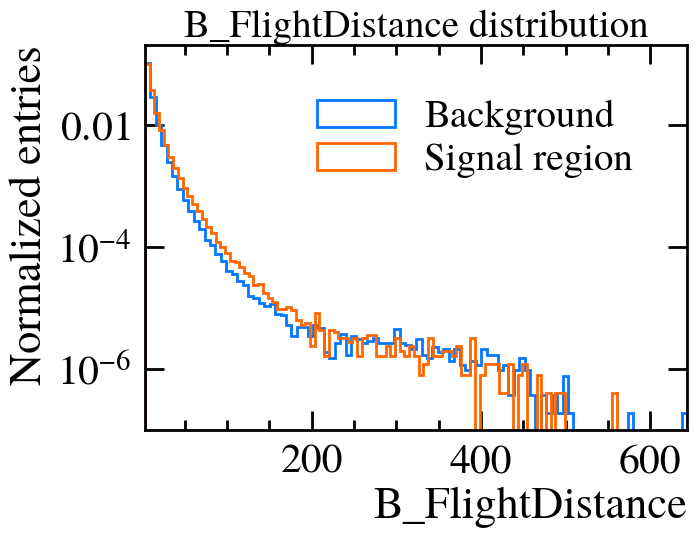

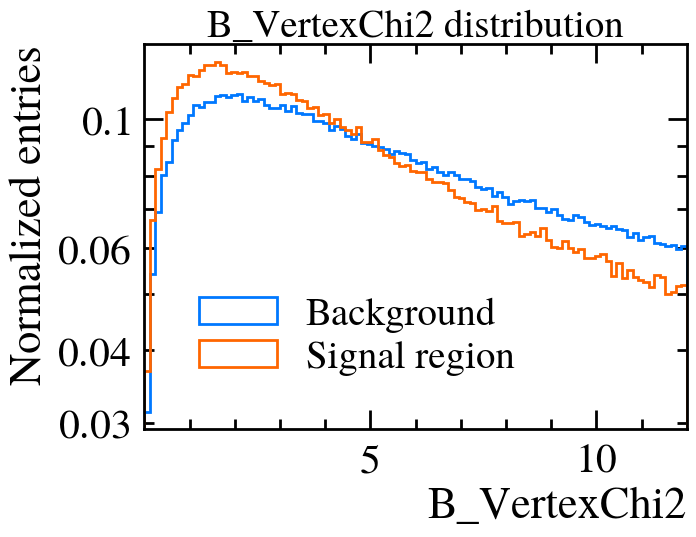

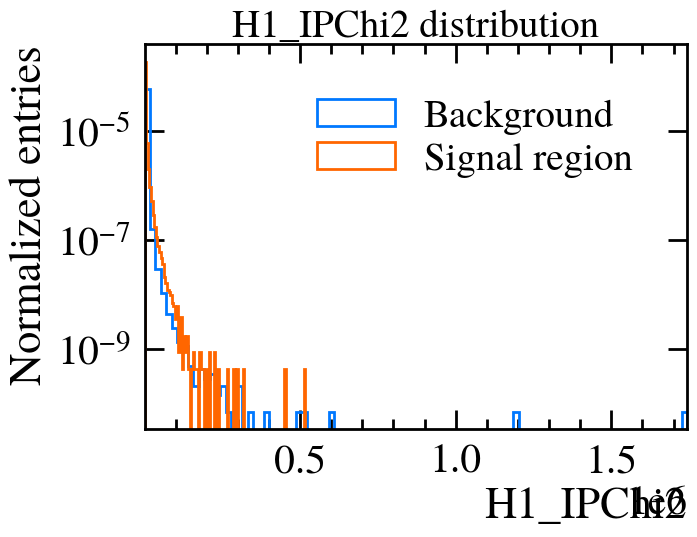

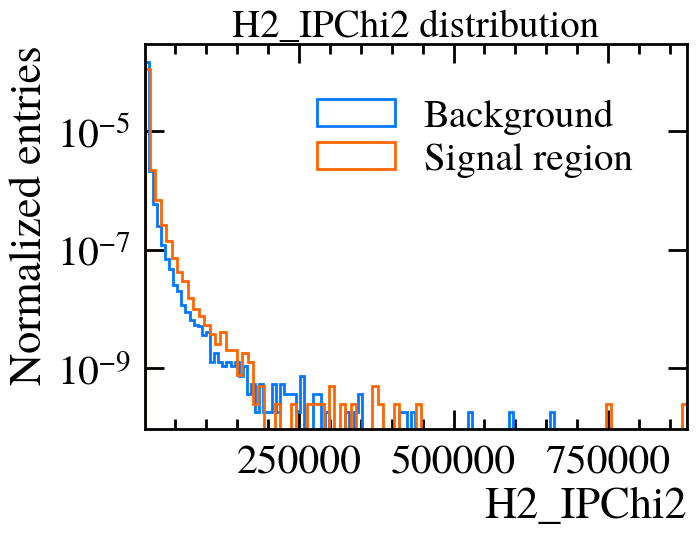

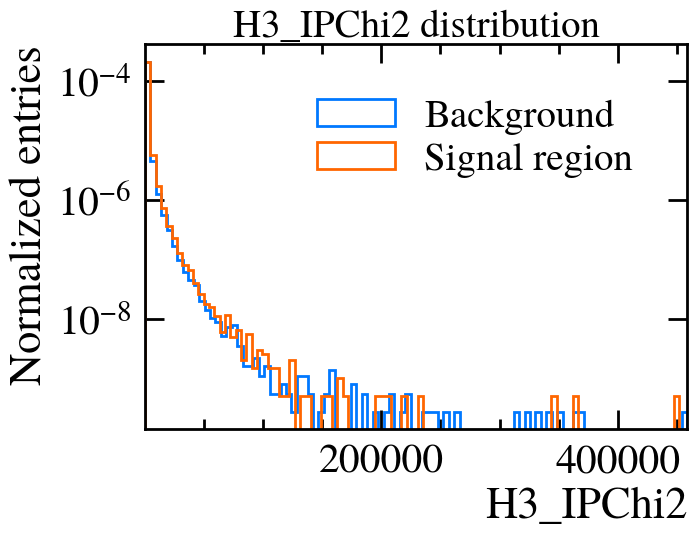

In [6]:
# ================================
# Variable comparison: signal vs background
# ================================

variables = [
    "B_FlightDistance",
    "B_VertexChi2",
    "H1_IPChi2",
    "H2_IPChi2",
    "H3_IPChi2"
]

for var in variables:
    plt.figure(figsize=(7,5))

    plt.hist(df_sideband[var], bins=100, density=True,
             histtype="step", label="Background")

    plt.hist(df_signal[var], bins=100, density=True,
             histtype="step", label="Signal region")

    plt.yscale("log")

    plt.xlabel(var)
    plt.ylabel("Normalized entries")
    plt.title(f"{var} distribution")

    plt.legend()
    plt.savefig(f"../plots/{var}_comparison.png", dpi=300)
    plt.show()

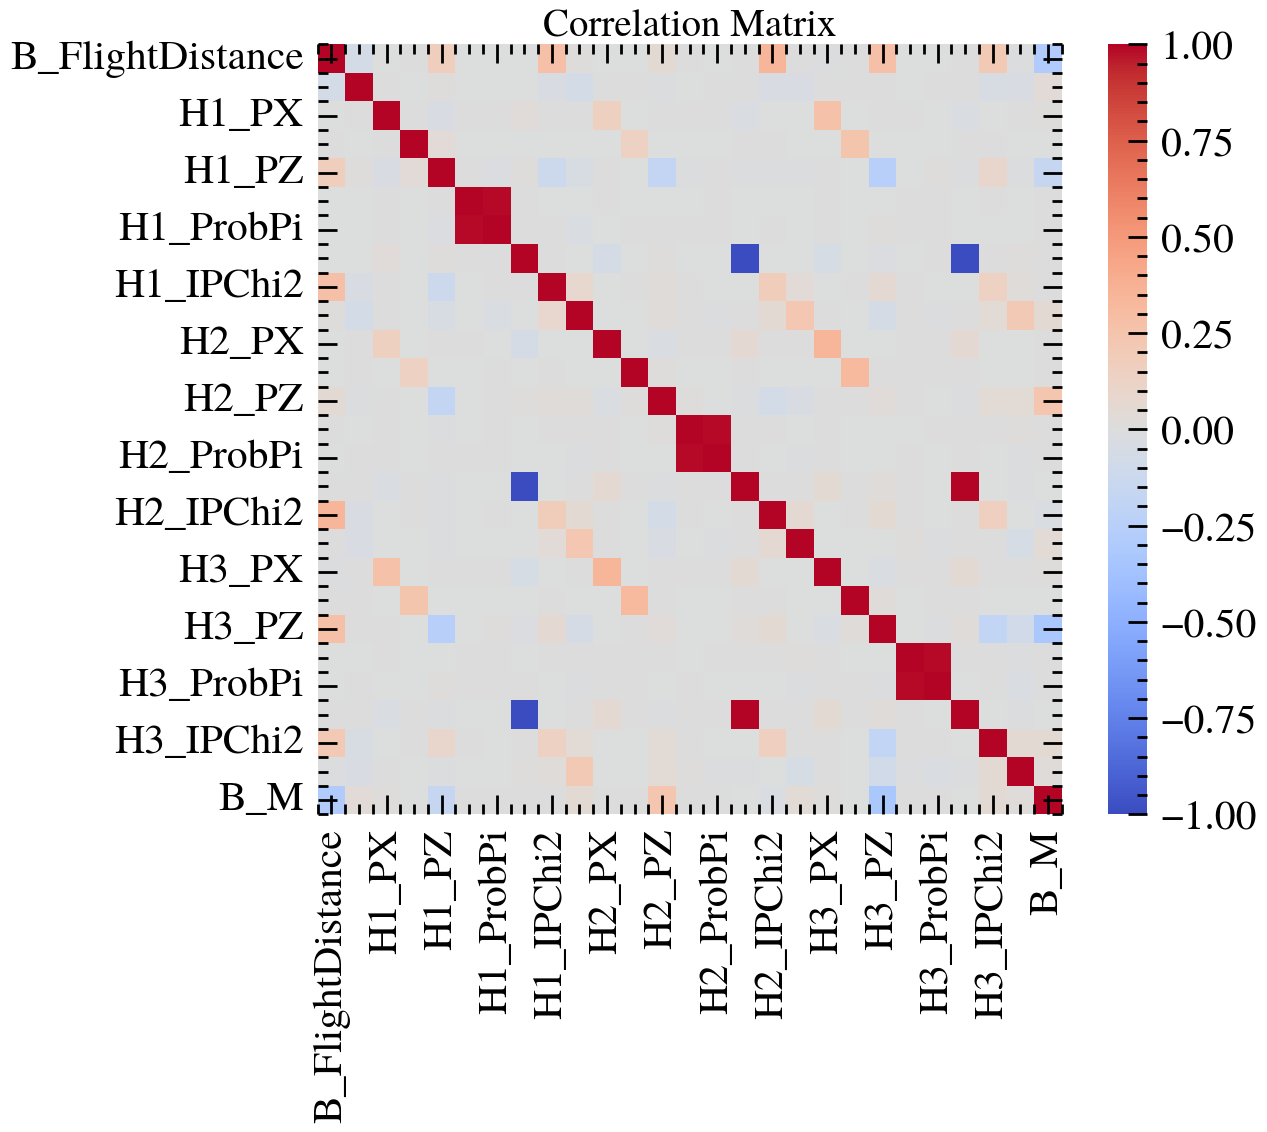

In [9]:
import seaborn as sns

df_numeric = df.select_dtypes(include=[np.number])

corr = df_numeric.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")

plt.savefig("D:/b_meson_analysis/plots/correlation_matrix.png", dpi=300)
plt.show()

In [10]:
# ================================
# Identify strongest correlations
# ================================

corr_unstacked = corr.abs().unstack()

# Remove self-correlations
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

# Sort
top_pairs = corr_unstacked.sort_values(ascending=False)

print("Top correlated pairs:\n")
print(top_pairs.head(10))

Top correlated pairs:

H1_ProbK          H1_ProbPi           0.989999
H1_ProbPi         H1_ProbK            0.989999
H3_ProbK          H3_ProbPi           0.987905
H3_ProbPi         H3_ProbK            0.987905
H2_ProbPi         H2_ProbK            0.985871
H2_ProbK          H2_ProbPi           0.985871
H2_PX             H3_PX               0.349394
H3_PX             H2_PX               0.349394
H2_IPChi2         B_FlightDistance    0.344366
B_FlightDistance  H2_IPChi2           0.344366
dtype: float64


Key Physical Correlations:

1. FlightDistance ↔ IPChi2:
   - Long-lived B mesons decay far from the primary vertex
   - Larger displacement → larger impact parameter significance

2. VertexChi2:
   - Measures quality of decay vertex reconstruction
   - Signal typically has well-defined vertex → lower χ²

3. Track IPChi2:
   - Tracks from B decay are displaced
   - Background tracks originate near PV → lower IPChi2

These variables provide strong separation power for multivariate analysis (BDT).

In [11]:
# ================================
# Blinding function
# ================================

def blind_signal_region(df):
    """
    Remove signal region to avoid bias in analysis.
    """
    blinded = df[
        (df["B_M"] < signal_window[0]) |
        (df["B_M"] > signal_window[1])
    ]

    print("Signal region blinded — do not look until analysis frozen")
    return blinded


df_blinded = blind_signal_region(df)

print("Blinded dataset size:", df_blinded.shape)

Signal region blinded — do not look until analysis frozen
Blinded dataset size: (4690956, 27)
